# Konversi Label Polygon Roboflow ke YOLOv8 Bounding Box

Notebook ini disiapkan untuk project **ALPR Lampung License Plate Detection**. Dataset berasal dari Roboflow dan disimpan di Google Drive dengan folder utama `ALPR-Lampung`. Label awal berasal dari Roboflow Auto Label berbasis SAM/Masks, sehingga anotasi yang diexport masih berbentuk polygon atau segmentation mask.

Pipeline project ini menggunakan **YOLOv8 object detection** untuk mendeteksi lokasi plat nomor kendaraan. Setelah plat terdeteksi, area plat dapat di-crop dan diteruskan ke PaddleOCR untuk membaca teks plat. Karena model YOLO yang akan dilatih adalah model deteksi objek biasa, label polygon perlu dikonversi menjadi bounding box YOLO dengan format:

```text
class_id x_center y_center width height
```

Notebook ini hanya melakukan konversi, validasi, pembuatan report, dan visualisasi hasil bounding box. Notebook ini **tidak melakukan training YOLO** dan **tidak melakukan split train/valid/test**. Split lanjutan, misalnya berdasarkan `ground_truth.csv`, sebaiknya dilakukan di notebook terpisah setelah label bounding box sudah terbukti valid secara visual.

## 1. Mount Google Drive

Cell ini menghubungkan Google Colab dengan Google Drive. Pastikan folder dataset `ALPR-Lampung` sudah berada di `MyDrive`, atau tambahkan shortcut folder Google Drive tersebut ke `MyDrive` sebelum menjalankan cell berikutnya.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Konfigurasi Path Dataset

Dataset input dibaca dari:

```text
/content/drive/MyDrive/ALPR-Lampung
```

Output hasil konversi akan dibuat pada folder baru:

```text
/content/drive/MyDrive/ALPR-Lampung-bbox
```

Folder input asli dari Roboflow tidak akan diubah. Jika folder output sudah ada dan `OVERWRITE_OUTPUT=True`, hanya folder output lama yang akan dihapus agar konversi dapat dijalankan ulang secara bersih.

In [ ]:
from pathlib import Path
import csv
import math
import random
import shutil
import subprocess
import sys
from collections import Counter, defaultdict

try:
    import yaml
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pyyaml'])
    import yaml

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATASET_ROOT = "/content/drive/MyDrive/ALPR-Lampung"
OUTPUT_ROOT = "/content/drive/MyDrive/ALPR-Lampung-bbox"

DATASET_ROOT_PATH = Path(DATASET_ROOT)
OUTPUT_ROOT_PATH = Path(OUTPUT_ROOT)

OVERWRITE_OUTPUT = True
SPLITS = ['train', 'valid', 'test']
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
CLASS_NAMES = ['license_plate']
EXPECTED_NC = 1
EXPECTED_CLASS_ID = 0
RANDOM_SEED = 42
N_VISUALIZE = 16  # boleh diubah antara 10 sampai 20

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Dataset input :', DATASET_ROOT_PATH)
print('Dataset output:', OUTPUT_ROOT_PATH)

Dataset input : /content/drive/MyDrive/ALPR-Lampung
Dataset output: /content/drive/MyDrive/ALPR-Lampung-bbox


## 3. Pemeriksaan Folder Google Drive

Cell ini memeriksa apakah folder `ALPR-Lampung` benar-benar tersedia pada `MyDrive`. Jika tidak ditemukan, notebook akan berhenti dengan instruksi yang jelas. Kasus paling umum adalah folder belum disalin ke `MyDrive`, atau folder shared Drive belum ditambahkan sebagai shortcut ke `MyDrive`.

In [ ]:
if not DATASET_ROOT_PATH.exists():
    raise FileNotFoundError(
        "Folder dataset tidak ditemukan: /content/drive/MyDrive/ALPR-Lampung\n\n"
        "Instruksi perbaikan:\n"
        "1. Pastikan folder ALPR-Lampung ada di MyDrive Google Drive Anda, atau\n"
        "2. Jika folder berasal dari link shared Drive, tambahkan shortcut folder tersebut ke MyDrive, lalu jalankan ulang notebook.\n\n"
        "Link folder yang diberikan: https://drive.google.com/drive/folders/1ZdrvJs4iUncuUBazRwVr8bXrLsvYXcI5?usp=sharing"
    )

if OUTPUT_ROOT_PATH.resolve() == DATASET_ROOT_PATH.resolve():
    raise ValueError('OUTPUT_ROOT tidak boleh sama dengan DATASET_ROOT agar dataset asli tetap aman.')

print('Folder dataset ditemukan.')
print('Isi folder root:')
for item in sorted(DATASET_ROOT_PATH.iterdir()):
    print('-', item.name)

Folder dataset ditemukan.
Isi folder root:
- README.roboflow.txt
- data.yaml
- train


## 4. Cek Struktur Dataset Awal

Struktur dataset saat ini berisi split `train` saja:

```text
ALPR-Lampung/
├── data.yaml
├── README.roboflow.txt
└── train/
    ├── images/
    └── labels/
```

Notebook tetap memeriksa `valid` dan `test`. Jika kedua split tersebut belum ada, notebook tidak akan error dan proses hanya dilakukan pada `train`.

In [ ]:
def list_files_by_ext(directory: Path, extensions):
    if not directory.exists():
        return []
    return sorted([p for p in directory.iterdir() if p.is_file() and p.suffix.lower() in extensions])


def list_label_files(directory: Path):
    if not directory.exists():
        return []
    return sorted([p for p in directory.iterdir() if p.is_file() and p.suffix.lower() == '.txt'])


def split_has_images_or_labels(root: Path, split: str):
    image_dir = root / split / 'images'
    label_dir = root / split / 'labels'
    return image_dir.exists() or label_dir.exists()


structure_rows = []
available_splits = []

for split in SPLITS:
    image_dir = DATASET_ROOT_PATH / split / 'images'
    label_dir = DATASET_ROOT_PATH / split / 'labels'
    images = list_files_by_ext(image_dir, IMAGE_EXTS)
    labels = list_label_files(label_dir)
    split_available = split_has_images_or_labels(DATASET_ROOT_PATH, split)

    if split_available:
        available_splits.append(split)

    structure_rows.append({
        'split': split,
        'split_available': split_available,
        'image_dir_exists': image_dir.exists(),
        'label_dir_exists': label_dir.exists(),
        'num_images': len(images),
        'num_labels': len(labels),
    })

structure_df = pd.DataFrame(structure_rows)
display(structure_df)

if 'train' not in available_splits:
    raise FileNotFoundError('Split train tidak ditemukan. Pastikan train/images dan train/labels tersedia di ALPR-Lampung.')

missing_eval_splits = [s for s in ['valid', 'test'] if s not in available_splits]
if missing_eval_splits == ['valid', 'test']:
    print('Warning: Split valid/test tidak ditemukan, proses hanya dilakukan pada train.')
elif missing_eval_splits:
    print(f"Warning: Split {', '.join(missing_eval_splits)} tidak ditemukan. Split tersebut akan dilewati.")
else:
    print('Split train, valid, dan test ditemukan. Semua split akan diproses.')

source_yaml_path = DATASET_ROOT_PATH / 'data.yaml'
if source_yaml_path.exists():
    print('\nIsi data.yaml sumber:')
    print(source_yaml_path.read_text())
else:
    print('\nWarning: data.yaml sumber tidak ditemukan. Notebook tetap akan membuat data.yaml baru pada folder output.')

,split,split_available,image_dir_exists,label_dir_exists,num_images,num_labels
0,train,True,True,True,185,185
1,valid,False,False,False,0,0
2,test,False,False,False,0,0



Isi data.yaml sumber:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['license_plate']

roboflow:
  workspace: hibbans-workspace-jdave
  project: hibbans-workspace-jdave
  version: dataset
  license: Private
  url: https://app.roboflow.com/hibbans-workspace-jdave/hibbans-workspace-jdave/dataset


## 5. Validasi Awal Pasangan Image dan Label pada Train

Sebelum konversi, notebook memeriksa jumlah gambar pada `train/images`, jumlah label pada `train/labels`, serta pasangan file berdasarkan nama stem. Contoh: `abc.jpg` harus memiliki label `abc.txt`.

Pemeriksaan ini penting karena YOLOv8 mengharapkan setiap image memiliki file label pasangan, walaupun file label tersebut boleh kosong jika tidak ada objek.

In [ ]:
def build_stem_map(paths):
    stem_map = {}
    duplicates = []
    for path in paths:
        if path.stem in stem_map:
            duplicates.append(path.stem)
        stem_map[path.stem] = path
    return stem_map, duplicates


train_image_dir = DATASET_ROOT_PATH / 'train' / 'images'
train_label_dir = DATASET_ROOT_PATH / 'train' / 'labels'
train_images = list_files_by_ext(train_image_dir, IMAGE_EXTS)
train_labels = list_label_files(train_label_dir)
train_image_map, duplicate_train_image_stems = build_stem_map(train_images)
train_label_map, duplicate_train_label_stems = build_stem_map(train_labels)

missing_train_labels = sorted(set(train_image_map) - set(train_label_map))
orphan_train_labels = sorted(set(train_label_map) - set(train_image_map))

print('Jumlah gambar train/images:', len(train_images))
print('Jumlah label  train/labels:', len(train_labels))
print('Gambar tanpa label pasangan:', len(missing_train_labels))
print('Label tanpa gambar pasangan:', len(orphan_train_labels))

if missing_train_labels[:10]:
    print('Contoh gambar tanpa label:', missing_train_labels[:10])
if orphan_train_labels[:10]:
    print('Contoh label tanpa gambar:', orphan_train_labels[:10])
if duplicate_train_image_stems:
    print('Warning duplikasi stem image:', duplicate_train_image_stems[:10])
if duplicate_train_label_stems:
    print('Warning duplikasi stem label:', duplicate_train_label_stems[:10])

Jumlah gambar train/images: 185
Jumlah label  train/labels: 185
Gambar tanpa label pasangan: 0
Label tanpa gambar pasangan: 0


## 6. Fungsi Deteksi Format Label

Label YOLO detection memiliki 5 kolom:

```text
class_id x_center y_center width height
```

Label polygon/segmentation memiliki lebih dari 5 kolom:

```text
class_id x1 y1 x2 y2 x3 y3 ... xn yn
```

Fungsi berikut mendeteksi apakah satu baris label sudah berupa bbox, masih berupa polygon, kosong, atau tidak valid. Bagian ini secara eksplisit digunakan untuk cek apakah isi label masih polygon atau sudah bbox.

In [ ]:
def parse_class_id(value):
    class_float = float(value)
    class_int = int(class_float)
    if not math.isclose(class_float, class_int):
        raise ValueError(f'class_id bukan bilangan bulat: {value}')
    return class_int


def detect_label_format(line: str):
    stripped = line.strip()
    if stripped == '':
        return 'empty', None, 'Baris kosong.'

    parts = stripped.split()
    if len(parts) < 5:
        return 'invalid', None, f'Jumlah kolom terlalu sedikit: {len(parts)}.'

    try:
        class_id = parse_class_id(parts[0])
        values = [float(v) for v in parts[1:]]
    except Exception as exc:
        return 'invalid', None, f'Gagal parsing angka: {exc}'

    if len(parts) == 5:
        return 'bbox', {'class_id': class_id, 'values': values}, 'Label sudah bbox YOLO.'

    if len(values) % 2 != 0:
        return 'invalid', None, f'Jumlah koordinat polygon tidak genap: {len(values)}.'

    if len(values) < 6:
        return 'invalid', None, 'Polygon perlu minimal 3 titik atau 6 angka koordinat.'

    return 'polygon', {'class_id': class_id, 'values': values}, 'Label polygon/segmentation.'


def inspect_label_file_format(label_path: Path):
    counts = Counter()
    for line in label_path.read_text().splitlines():
        label_format, _, _ = detect_label_format(line)
        counts[label_format] += 1
    if sum(counts.values()) == 0:
        counts['empty_file'] += 1
    return counts


format_rows = []
for split in available_splits:
    for label_path in list_label_files(DATASET_ROOT_PATH / split / 'labels'):
        counts = inspect_label_file_format(label_path)
        format_rows.append({
            'split': split,
            'label_file': label_path.name,
            'bbox_lines': counts.get('bbox', 0),
            'polygon_lines': counts.get('polygon', 0),
            'invalid_lines': counts.get('invalid', 0),
            'empty_lines': counts.get('empty', 0),
            'empty_file': counts.get('empty_file', 0),
        })

format_df = pd.DataFrame(format_rows)
if len(format_df) > 0:
    display(format_df.head(20))
    print('Total baris bbox awal   :', int(format_df['bbox_lines'].sum()))
    print('Total baris polygon awal:', int(format_df['polygon_lines'].sum()))
    print('Total baris invalid awal:', int(format_df['invalid_lines'].sum()))
else:
    print('Tidak ada file label untuk diperiksa.')

,split,label_file,bbox_lines,polygon_lines,invalid_lines,empty_lines,empty_file
0,train,alpr_lampung_000001_jpg.rf.uj1dwJiAHNTmuRgVh3m...,0,1,0,0,0
1,train,alpr_lampung_000002_jpg.rf.fV8BWpHPHSX3Oygcb3i...,0,1,0,0,0
2,train,alpr_lampung_000003_jpg.rf.kmQzGkq7MitzNHbZwv3...,0,1,0,0,0
3,train,alpr_lampung_000004_jpg.rf.CMGOrgRq2OwqdrDm2wy...,0,1,0,0,0
4,train,alpr_lampung_000005_jpg.rf.PL6q3vzntvvpNh4Ujhx...,0,1,0,0,0
5,train,alpr_lampung_000006_jpg.rf.rf2bCUMYfwnmDoz4PaH...,0,1,0,0,0
6,train,alpr_lampung_000007_jpg.rf.AOPJbJ9JpRVO8y0CznY...,0,1,0,0,0
7,train,alpr_lampung_000008_jpg.rf.OlSMDQjaqau7sVLo9nf...,0,1,0,0,0
8,train,alpr_lampung_000009_jpg.rf.u4LZbnJ4aS56kOpLA5v...,0,1,0,0,0
9,train,alpr_lampung_000010_jpg.rf.8R5E3riORsTkHWNw6dJ...,0,1,0,0,0


Total baris bbox awal   : 0
Total baris polygon awal: 189
Total baris invalid awal: 0


## 7. Fungsi Konversi Polygon ke Bounding Box YOLO

Konversi dilakukan dengan mengambil batas minimum dan maksimum dari seluruh titik polygon. Semua nilai koordinat di-clip ke rentang `0` sampai `1`, karena YOLO menggunakan koordinat ter-normalisasi.

Rumus yang digunakan:

```text
x_min = min(x polygon)
x_max = max(x polygon)
y_min = min(y polygon)
y_max = max(y polygon)

x_center = (x_min + x_max) / 2
y_center = (y_min + y_max) / 2
width    = x_max - x_min
height   = y_max - y_min
```

In [ ]:
def clip01(value):
    return min(1.0, max(0.0, float(value)))


def validate_class_id(class_id):
    if class_id != EXPECTED_CLASS_ID:
        raise ValueError(f'class_id harus {EXPECTED_CLASS_ID}, tetapi ditemukan {class_id}.')


def format_yolo_row(class_id, x_center, y_center, width, height):
    return f'{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}'


def polygon_to_yolo_bbox(class_id, polygon_values):
    validate_class_id(class_id)
    clipped_values = [clip01(v) for v in polygon_values]
    xs = clipped_values[0::2]
    ys = clipped_values[1::2]

    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    width = x_max - x_min
    height = y_max - y_min

    if width <= 0 or height <= 0:
        raise ValueError(f'BBox tidak valid: width={width}, height={height}.')

    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2

    return [class_id, clip01(x_center), clip01(y_center), clip01(width), clip01(height)]


def normalize_existing_bbox(class_id, bbox_values):
    validate_class_id(class_id)
    if len(bbox_values) != 4:
        raise ValueError(f'BBox harus memiliki 4 nilai, ditemukan {len(bbox_values)}.')

    x_center, y_center, width, height = [clip01(v) for v in bbox_values]
    if width <= 0 or height <= 0:
        raise ValueError(f'BBox tidak valid: width={width}, height={height}.')

    return [class_id, x_center, y_center, width, height]


example_polygon = [0.1915, 0.6985, 0.4258, 0.7368, 0.4214, 0.8023, 0.1948, 0.7601]
print(format_yolo_row(*polygon_to_yolo_bbox(0, example_polygon)))

0 0.308650 0.750400 0.234300 0.103800


## 8. Fungsi Konversi Satu File Label

Satu file label dapat berisi satu atau lebih objek. Untuk setiap baris:

1. Jika sudah bbox YOLO 5 kolom, label dipertahankan dan dinormalisasi.
2. Jika masih polygon, label dikonversi ke bbox.
3. Jika file kosong, file output kosong tetap dibuat dan dicatat sebagai warning.
4. Jika jumlah koordinat polygon tidak genap, baris dicatat sebagai error dan dilewati.
5. Jika bbox memiliki width atau height tidak valid, baris dicatat sebagai error.

In [ ]:
def convert_label_file(input_label_path: Path, output_label_path: Path):
    raw_text = input_label_path.read_text().strip('\n')
    lines = raw_text.splitlines() if raw_text else []

    output_rows = []
    notes = []
    num_before = sum(1 for line in lines if line.strip())
    num_errors = 0
    num_warnings = 0
    num_polygons = 0
    num_bboxes = 0

    if len(lines) == 0:
        output_label_path.write_text('')
        return {
            'status': 'warning',
            'num_objects_before': 0,
            'num_objects_after': 0,
            'notes': 'Label kosong. File label kosong tetap dibuat.',
        }

    for line_idx, line in enumerate(lines, start=1):
        label_format, parsed, note = detect_label_format(line)

        if label_format == 'empty':
            num_warnings += 1
            notes.append(f'line {line_idx}: baris kosong dilewati')
            continue

        if label_format == 'invalid':
            num_errors += 1
            notes.append(f'line {line_idx}: ERROR - {note}')
            continue

        class_id = parsed['class_id']
        values = parsed['values']

        try:
            if label_format == 'bbox':
                bbox = normalize_existing_bbox(class_id, values)
                num_bboxes += 1
            elif label_format == 'polygon':
                bbox = polygon_to_yolo_bbox(class_id, values)
                num_polygons += 1
            else:
                raise ValueError(f'Format tidak dikenal: {label_format}')

            output_rows.append(format_yolo_row(*bbox))

        except Exception as exc:
            num_errors += 1
            notes.append(f'line {line_idx}: ERROR - {exc}')

    output_label_path.write_text('\n'.join(output_rows) + ('\n' if output_rows else ''))

    if num_errors > 0:
        status = 'error'
    elif num_warnings > 0 or len(output_rows) == 0:
        status = 'warning'
    else:
        status = 'success'

    summary_note = f'polygon_converted={num_polygons}; bbox_kept={num_bboxes}'
    if notes:
        summary_note += '; ' + ' | '.join(notes)

    return {
        'status': status,
        'num_objects_before': num_before,
        'num_objects_after': len(output_rows),
        'notes': summary_note,
    }

## 9. Proses Konversi Dataset

Cell ini memproses split yang tersedia. Untuk kondisi dataset saat ini, hanya `train` yang akan diproses. Jika `valid` atau `test` nanti ditambahkan ke folder `ALPR-Lampung`, notebook akan ikut memprosesnya tanpa perlu mengubah kode utama.

Semua file image disalin ke folder output. Semua file label dikonversi ke format YOLO bbox dan disimpan di folder output. Dataset asli di `ALPR-Lampung` tidak disentuh.

In [ ]:
if OUTPUT_ROOT_PATH.exists():
    if OVERWRITE_OUTPUT:
        shutil.rmtree(OUTPUT_ROOT_PATH)
        print('Folder output lama dihapus:', OUTPUT_ROOT_PATH)
    else:
        raise FileExistsError(
            f'Folder output sudah ada: {OUTPUT_ROOT_PATH}. '
            'Set OVERWRITE_OUTPUT=True atau ganti OUTPUT_ROOT.'
        )

report_rows = []
processed_splits = []

for split in SPLITS:
    if split not in available_splits:
        continue

    input_image_dir = DATASET_ROOT_PATH / split / 'images'
    input_label_dir = DATASET_ROOT_PATH / split / 'labels'
    output_image_dir = OUTPUT_ROOT_PATH / split / 'images'
    output_label_dir = OUTPUT_ROOT_PATH / split / 'labels'

    output_image_dir.mkdir(parents=True, exist_ok=True)
    output_label_dir.mkdir(parents=True, exist_ok=True)
    processed_splits.append(split)

    input_images = list_files_by_ext(input_image_dir, IMAGE_EXTS)
    input_labels = list_label_files(input_label_dir)
    image_map, duplicate_image_stems = build_stem_map(input_images)
    label_map, duplicate_label_stems = build_stem_map(input_labels)

    print(f'\nMemproses split {split}: {len(input_images)} images, {len(input_labels)} labels')

    for stem, image_path in image_map.items():
        target_image_path = output_image_dir / image_path.name
        shutil.copy2(image_path, target_image_path)

        input_label_path = label_map.get(stem)
        output_label_path = output_label_dir / f'{stem}.txt'

        if input_label_path is None:
            output_label_path.write_text('')
            report_rows.append({
                'split': split,
                'label_file': output_label_path.name,
                'status': 'warning',
                'num_objects_before': 0,
                'num_objects_after': 0,
                'notes': 'Image tidak memiliki label pasangan. File label kosong dibuat.',
            })
            continue

        result = convert_label_file(input_label_path, output_label_path)
        report_rows.append({
            'split': split,
            'label_file': output_label_path.name,
            **result,
        })

    orphan_label_stems = sorted(set(label_map) - set(image_map))
    for stem in orphan_label_stems:
        report_rows.append({
            'split': split,
            'label_file': label_map[stem].name,
            'status': 'warning',
            'num_objects_before': sum(1 for line in label_map[stem].read_text().splitlines() if line.strip()),
            'num_objects_after': 0,
            'notes': 'Label tidak memiliki image pasangan. Label tidak disalin ke output.',
        })

    for stem in duplicate_image_stems:
        report_rows.append({
            'split': split,
            'label_file': '',
            'status': 'warning',
            'num_objects_before': 0,
            'num_objects_after': 0,
            'notes': f'Duplikasi stem image terdeteksi: {stem}. Periksa manual.',
        })

    for stem in duplicate_label_stems:
        report_rows.append({
            'split': split,
            'label_file': f'{stem}.txt',
            'status': 'warning',
            'num_objects_before': 0,
            'num_objects_after': 0,
            'notes': f'Duplikasi stem label terdeteksi: {stem}. Periksa manual.',
        })

report_df = pd.DataFrame(report_rows, columns=[
    'split', 'label_file', 'status', 'num_objects_before', 'num_objects_after', 'notes'
])

display(report_df.head(20))
print('Split yang diproses:', processed_splits)
print('Total baris report:', len(report_df))
print('Status report:', dict(report_df['status'].value_counts()))


Memproses split train: 185 images, 185 labels


,split,label_file,status,num_objects_before,num_objects_after,notes
0,train,alpr_lampung_000001_jpg.rf.uj1dwJiAHNTmuRgVh3m...,success,1,1,polygon_converted=1; bbox_kept=0
1,train,alpr_lampung_000002_jpg.rf.fV8BWpHPHSX3Oygcb3i...,success,1,1,polygon_converted=1; bbox_kept=0
2,train,alpr_lampung_000003_jpg.rf.kmQzGkq7MitzNHbZwv3...,success,1,1,polygon_converted=1; bbox_kept=0
3,train,alpr_lampung_000004_jpg.rf.CMGOrgRq2OwqdrDm2wy...,success,1,1,polygon_converted=1; bbox_kept=0
4,train,alpr_lampung_000005_jpg.rf.PL6q3vzntvvpNh4Ujhx...,success,1,1,polygon_converted=1; bbox_kept=0
5,train,alpr_lampung_000006_jpg.rf.rf2bCUMYfwnmDoz4PaH...,success,1,1,polygon_converted=1; bbox_kept=0
6,train,alpr_lampung_000007_jpg.rf.AOPJbJ9JpRVO8y0CznY...,success,1,1,polygon_converted=1; bbox_kept=0
7,train,alpr_lampung_000008_jpg.rf.OlSMDQjaqau7sVLo9nf...,success,1,1,polygon_converted=1; bbox_kept=0
8,train,alpr_lampung_000009_jpg.rf.u4LZbnJ4aS56kOpLA5v...,success,1,1,polygon_converted=1; bbox_kept=0
9,train,alpr_lampung_000010_jpg.rf.8R5E3riORsTkHWNw6dJ...,success,1,1,polygon_converted=1; bbox_kept=0


Split yang diproses: ['train']
Total baris report: 185
Status report: {'success': np.int64(185)}


## 10. Pembuatan `data.yaml` Baru

File `data.yaml` dibuat di folder output `ALPR-Lampung-bbox`. Karena dataset saat ini belum memiliki split valid, field `val` sementara diarahkan ke `train/images` agar format YAML tetap dapat dibaca oleh YOLOv8. Ketika split valid sudah dibuat pada notebook terpisah, ubah `val` menjadi `valid/images`.

Jika `test` tersedia, field `test` akan ditambahkan. Jika belum tersedia, field `test` tidak ditulis.

In [ ]:
has_valid = 'valid' in processed_splits
has_test = 'test' in processed_splits

output_yaml_lines = [
    f'path: {OUTPUT_ROOT_PATH.resolve()}',
    'train: train/images',
]

if has_valid:
    output_yaml_lines.append('val: valid/images')
else:
    output_yaml_lines.append('# valid split belum tersedia; sementara val diarahkan ke train/images')
    output_yaml_lines.append('val: train/images')

if has_test:
    output_yaml_lines.append('test: test/images')

output_yaml_lines.extend([
    'nc: 1',
    "names: ['license_plate']",
])

output_yaml_text = '\n'.join(output_yaml_lines) + '\n'
output_yaml_path = OUTPUT_ROOT_PATH / 'data.yaml'
output_yaml_path.write_text(output_yaml_text)

print(output_yaml_path)
print(output_yaml_path.read_text())

/content/drive/MyDrive/ALPR-Lampung-bbox/data.yaml
path: /content/drive/MyDrive/ALPR-Lampung-bbox
train: train/images
# valid split belum tersedia; sementara val diarahkan ke train/images
val: train/images
nc: 1
names: ['license_plate']



## 11. Pembuatan `conversion_report.csv`

Report konversi disimpan sebagai CSV dengan kolom:

```text
split, label_file, status, num_objects_before, num_objects_after, notes
```

Gunakan file ini untuk meninjau warning dan error setelah konversi. Baris error biasanya perlu diperiksa manual karena dapat menandakan label rusak, jumlah koordinat polygon ganjil, class id tidak sesuai, atau bbox tidak valid.

In [ ]:
report_csv_path = OUTPUT_ROOT_PATH / 'conversion_report.csv'
report_df.to_csv(report_csv_path, index=False)

print('Report disimpan ke:', report_csv_path)
if len(report_df) > 0:
    display(report_df['status'].value_counts().rename_axis('status').reset_index(name='count'))
    display(report_df.tail(20))
else:
    print('Report kosong. Tidak ada file yang diproses.')

Report disimpan ke: /content/drive/MyDrive/ALPR-Lampung-bbox/conversion_report.csv


,status,count
0,success,185


,split,label_file,status,num_objects_before,num_objects_after,notes
165,train,alpr_lampung_000166_jpg.rf.tGQLDIsvSJAAg7HHepI...,success,1,1,polygon_converted=1; bbox_kept=0
166,train,alpr_lampung_000167_png.rf.tFez3OBkOyw8sNROlQQ...,success,1,1,polygon_converted=1; bbox_kept=0
167,train,alpr_lampung_000168_jpg.rf.IjWWYwu06Dak2gMgbfe...,success,1,1,polygon_converted=1; bbox_kept=0
168,train,alpr_lampung_000169_jpg.rf.xGO54ucKDQNDAeRr2cj...,success,1,1,polygon_converted=1; bbox_kept=0
169,train,alpr_lampung_000170_jpg.rf.Gk8ePYlsUNZlYZXDvc1...,success,2,2,polygon_converted=2; bbox_kept=0
170,train,alpr_lampung_000171_jpg.rf.pZgdKkUTefz4Or8rBHs...,success,1,1,polygon_converted=1; bbox_kept=0
171,train,alpr_lampung_000172_jpg.rf.lJbYno6effNnD2sHuMP...,success,1,1,polygon_converted=1; bbox_kept=0
172,train,alpr_lampung_000173_jpg.rf.pgOe8cGdNW0Oro1nTex...,success,1,1,polygon_converted=1; bbox_kept=0
173,train,alpr_lampung_000174_jpg.rf.DTORiAIxALQslaRPFrS...,success,1,1,polygon_converted=1; bbox_kept=0
174,train,alpr_lampung_000175_jpg.rf.WdDelvXc63un9ufdai7...,success,1,1,polygon_converted=1; bbox_kept=0


## 12. Validasi Dataset Hasil Konversi

Validasi ini memastikan dataset output sudah sesuai untuk YOLOv8 object detection:

1. Jumlah gambar dan label pada `train`.
2. Setiap gambar memiliki file label pasangan.
3. Setiap label memiliki gambar pasangan.
4. Setiap baris label output memiliki tepat 5 nilai.
5. Semua nilai bbox berada dalam rentang `0` sampai `1`.
6. `class_id` hanya bernilai `0`.
7. `data.yaml` berisi `nc: 1` dan `names: ['license_plate']`.

In [ ]:
def validate_yolo_bbox_label(label_path: Path):
    issues = []
    object_count = 0

    lines = label_path.read_text().splitlines() if label_path.exists() else []
    for line_idx, line in enumerate(lines, start=1):
        stripped = line.strip()
        if not stripped:
            continue

        parts = stripped.split()
        if len(parts) != 5:
            issues.append(f'line {line_idx}: jumlah nilai {len(parts)}, seharusnya 5')
            continue

        try:
            class_id = parse_class_id(parts[0])
            bbox_values = [float(v) for v in parts[1:]]
        except Exception as exc:
            issues.append(f'line {line_idx}: gagal parsing - {exc}')
            continue

        if class_id != EXPECTED_CLASS_ID:
            issues.append(f'line {line_idx}: class_id={class_id}, seharusnya {EXPECTED_CLASS_ID}')

        x_center, y_center, width, height = bbox_values
        if not all(0.0 <= v <= 1.0 for v in bbox_values):
            issues.append(f'line {line_idx}: bbox di luar rentang 0-1: {bbox_values}')

        if width <= 0 or height <= 0:
            issues.append(f'line {line_idx}: width/height tidak valid: width={width}, height={height}')

        object_count += 1

    return object_count, issues


validation_rows = []
label_issue_rows = []

for split in processed_splits:
    image_dir = OUTPUT_ROOT_PATH / split / 'images'
    label_dir = OUTPUT_ROOT_PATH / split / 'labels'

    images = list_files_by_ext(image_dir, IMAGE_EXTS)
    labels = list_label_files(label_dir)
    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    missing_labels = sorted(image_stems - label_stems)
    orphan_labels = sorted(label_stems - image_stems)

    total_objects = 0
    invalid_label_files = 0

    for label_path in labels:
        object_count, issues = validate_yolo_bbox_label(label_path)
        total_objects += object_count
        if issues:
            invalid_label_files += 1
            label_issue_rows.append({
                'split': split,
                'label_file': label_path.name,
                'issues': ' | '.join(issues[:10]),
            })

    validation_rows.append({
        'split': split,
        'num_images': len(images),
        'num_labels': len(labels),
        'missing_label_files': len(missing_labels),
        'orphan_label_files': len(orphan_labels),
        'total_objects': total_objects,
        'invalid_label_files': invalid_label_files,
    })

validation_df = pd.DataFrame(validation_rows)
label_issues_df = pd.DataFrame(label_issue_rows)

display(validation_df)

if len(label_issues_df) > 0:
    print('Ditemukan issue pada label hasil konversi:')
    display(label_issues_df.head(50))
else:
    print('Tidak ditemukan issue format bbox pada label hasil konversi.')

with output_yaml_path.open('r') as f:
    loaded_output_yaml = yaml.safe_load(f)

yaml_nc_ok = loaded_output_yaml.get('nc') == EXPECTED_NC
yaml_names_ok = loaded_output_yaml.get('names') == CLASS_NAMES

print('Validasi data.yaml nc   :', yaml_nc_ok, loaded_output_yaml.get('nc'))
print('Validasi data.yaml names:', yaml_names_ok, loaded_output_yaml.get('names'))

,split,num_images,num_labels,missing_label_files,orphan_label_files,total_objects,invalid_label_files
0,train,185,185,0,0,189,0


Tidak ditemukan issue format bbox pada label hasil konversi.
Validasi data.yaml nc   : True 1
Validasi data.yaml names: True ['license_plate']


## 13. Visualisasi Bounding Box Hasil Konversi

Visualisasi ini wajib dilakukan sebelum training. Notebook mengambil 10 sampai 20 gambar random dari:

```text
/content/drive/MyDrive/ALPR-Lampung-bbox/train/images
```

Label dibaca dari:

```text
/content/drive/MyDrive/ALPR-Lampung-bbox/train/labels
```

Jika mayoritas bbox sudah pas mengelilingi plat nomor, dataset hasil konversi dapat digunakan untuk training YOLOv8 object detection. Jika banyak bbox salah, label harus diperbaiki manual di Roboflow atau diedit sebelum training.

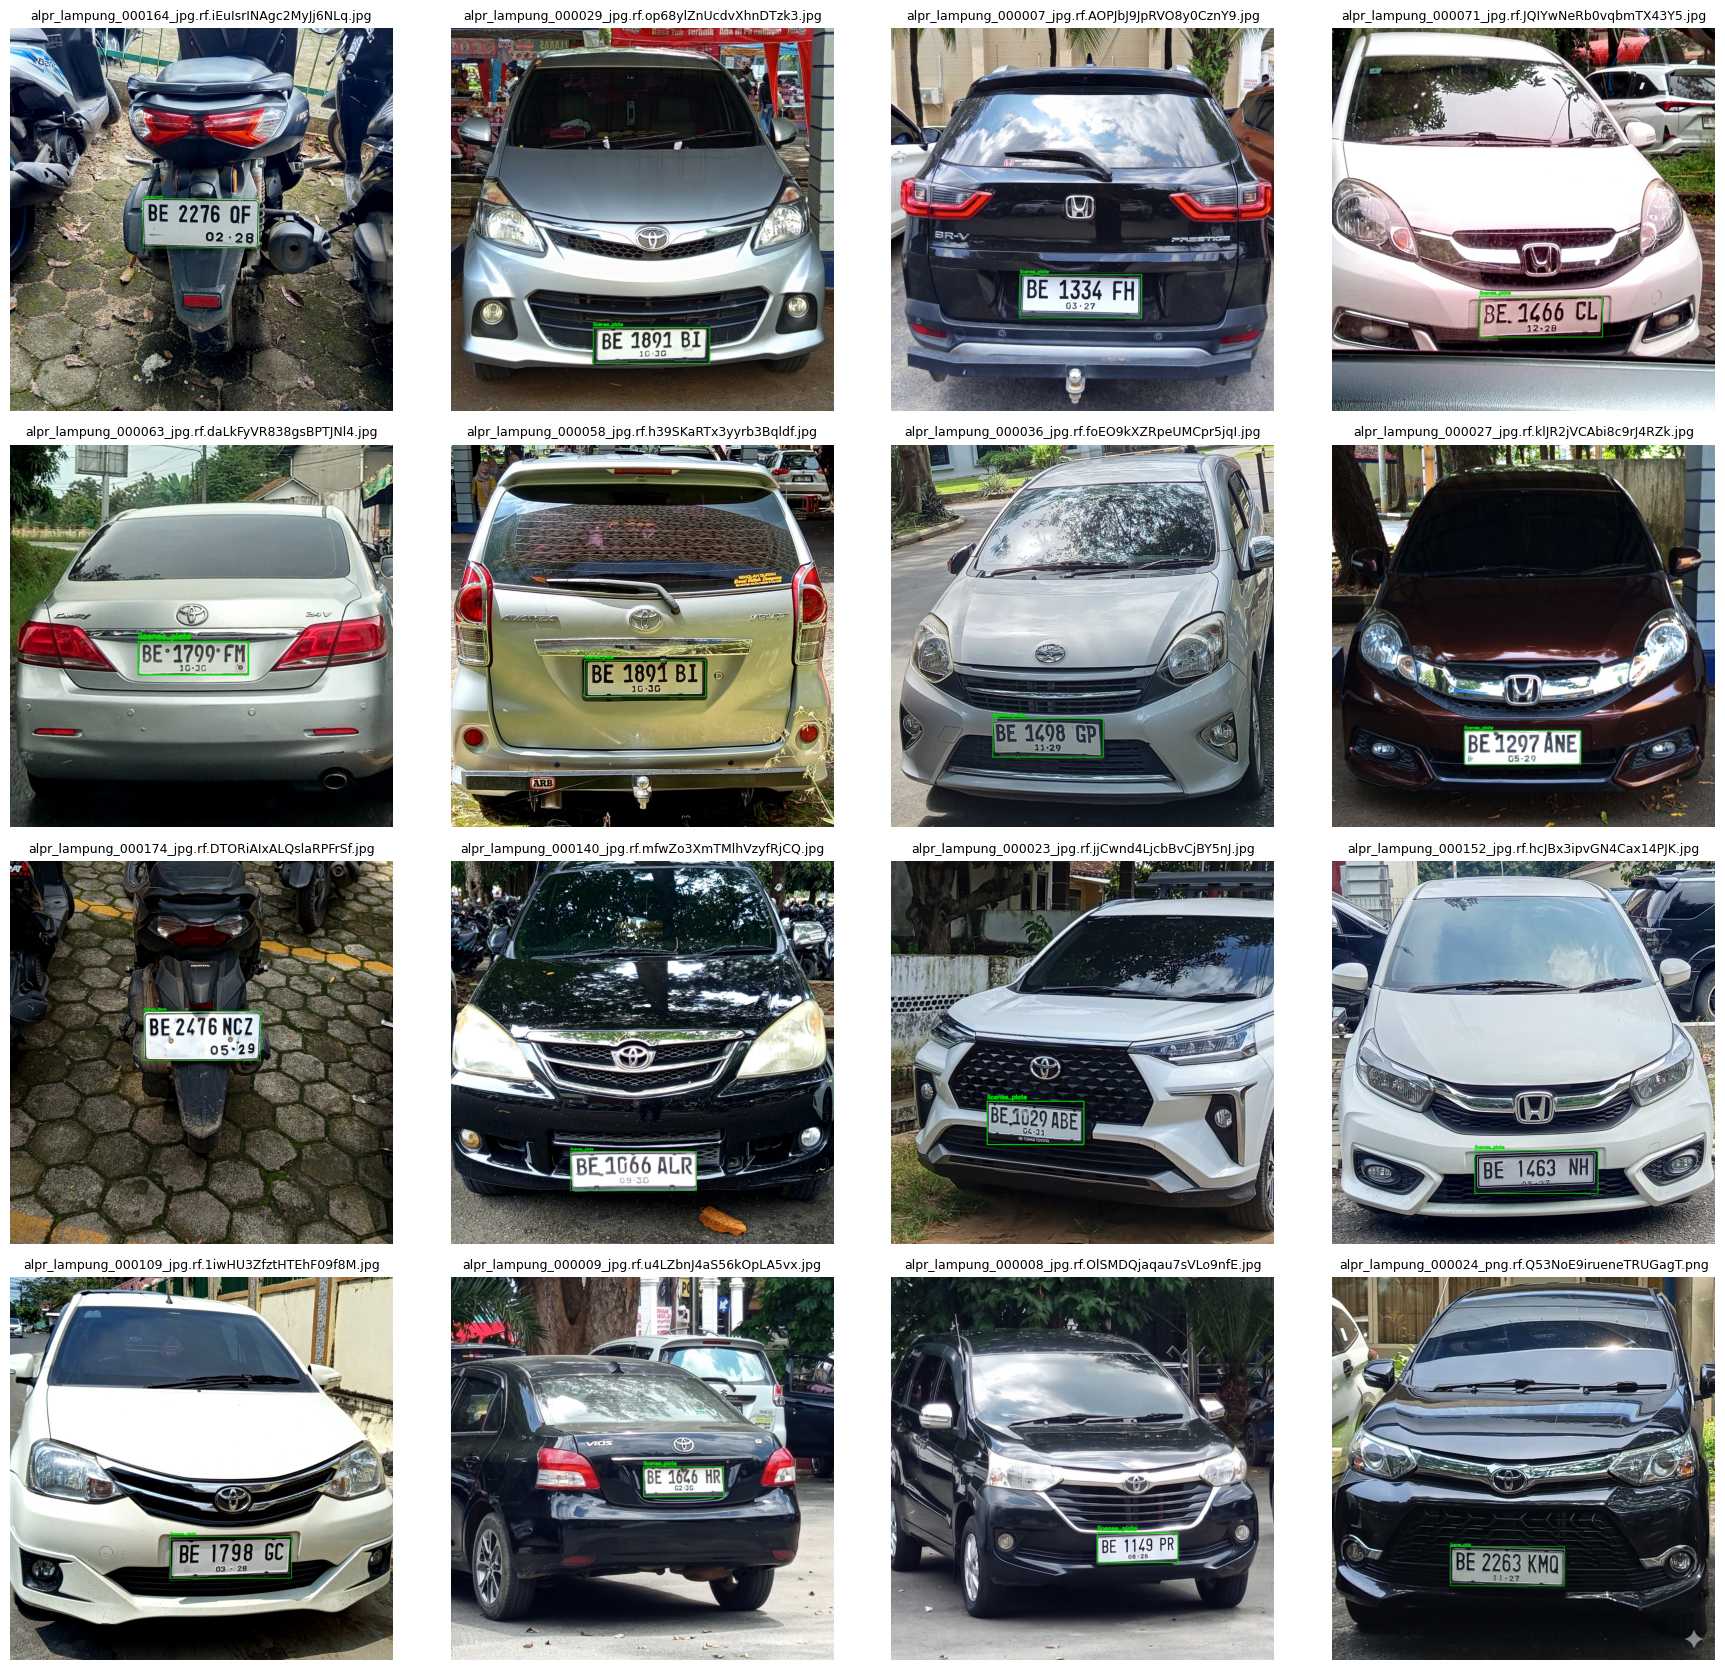

In [ ]:
def read_yolo_bboxes(label_path: Path):
    boxes = []
    if not label_path.exists():
        return boxes

    for line in label_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        try:
            class_id = parse_class_id(parts[0])
            x_center, y_center, width, height = [float(v) for v in parts[1:]]
        except Exception:
            continue
        boxes.append((class_id, x_center, y_center, width, height))
    return boxes


def draw_yolo_bboxes(image_path: Path, label_path: Path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise ValueError(f'Gagal membaca image: {image_path}')

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    img_h, img_w = image_rgb.shape[:2]

    for class_id, x_center, y_center, width, height in read_yolo_bboxes(label_path):
        x1 = int((x_center - width / 2) * img_w)
        y1 = int((y_center - height / 2) * img_h)
        x2 = int((x_center + width / 2) * img_w)
        y2 = int((y_center + height / 2) * img_h)

        x1 = max(0, min(img_w - 1, x1))
        y1 = max(0, min(img_h - 1, y1))
        x2 = max(0, min(img_w - 1, x2))
        y2 = max(0, min(img_h - 1, y2))

        cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (0, 220, 0), 2)
        label_text = CLASS_NAMES[class_id] if 0 <= class_id < len(CLASS_NAMES) else str(class_id)
        cv2.putText(
            image_rgb,
            label_text,
            (x1, max(15, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 220, 0),
            2,
            cv2.LINE_AA,
        )

    return image_rgb


train_output_image_dir = OUTPUT_ROOT_PATH / 'train' / 'images'
train_output_label_dir = OUTPUT_ROOT_PATH / 'train' / 'labels'
train_output_images = list_files_by_ext(train_output_image_dir, IMAGE_EXTS)

if len(train_output_images) == 0:
    print('Tidak ada gambar pada output train/images untuk divisualisasikan.')
else:
    sample_count = min(max(10, min(N_VISUALIZE, 20)), len(train_output_images))
    sampled_images = random.sample(train_output_images, sample_count)

    cols = 4
    rows = math.ceil(sample_count / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 4.2 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, image_path in zip(axes, sampled_images):
        label_path = train_output_label_dir / f'{image_path.stem}.txt'
        drawn = draw_yolo_bboxes(image_path, label_path)
        ax.imshow(drawn)
        ax.set_title(image_path.name, fontsize=9)
        ax.axis('off')

    for ax in axes[len(sampled_images):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## 14. Ringkasan Akhir

Bagian ini merangkum hasil konversi dan validasi. Status siap training pada bagian ini hanya berarti siap secara struktur dan format. Keputusan akhir tetap harus mempertimbangkan visualisasi bbox: bounding box harus benar-benar mengelilingi plat nomor secara konsisten.

Catatan penting: jika visualisasi menunjukkan banyak bbox salah, dataset harus diperbaiki manual di Roboflow atau label yang salah harus diedit. Namun jika mayoritas bbox sudah pas mengelilingi plat, dataset hasil konversi dapat digunakan untuk training YOLOv8 object detection.

In [ ]:
status_counts = report_df['status'].value_counts().to_dict() if len(report_df) else {}
num_errors = int(status_counts.get('error', 0))
num_warnings = int(status_counts.get('warning', 0))
num_success = int(status_counts.get('success', 0))

validation_has_issues = False
if len(validation_df) > 0:
    validation_has_issues = bool(
        (validation_df['missing_label_files'].sum() > 0) or
        (validation_df['orphan_label_files'].sum() > 0) or
        (validation_df['invalid_label_files'].sum() > 0)
    )

yaml_ok = yaml_nc_ok and yaml_names_ok
format_ready = (num_errors == 0) and (not validation_has_issues) and yaml_ok

print('Folder dataset hasil konversi:', OUTPUT_ROOT_PATH)
print('data.yaml baru               :', output_yaml_path)
print('conversion_report.csv        :', report_csv_path)
print('Split diproses               :', processed_splits)
print()
print('Jumlah file sukses :', num_success)
print('Jumlah warning     :', num_warnings)
print('Jumlah error       :', num_errors)
print()
print('Validasi data.yaml :', 'OK' if yaml_ok else 'BELUM OK')
print('Validasi label     :', 'OK' if not validation_has_issues else 'PERLU DICEK')
print()

if format_ready:
    print('Kesimpulan format: dataset sudah siap secara struktur dan format untuk training YOLOv8 object detection.')
    print('Tetap cek visualisasi. Jika mayoritas bbox mengelilingi plat dengan baik, dataset dapat digunakan untuk training.')
else:
    print('Kesimpulan format: dataset belum sepenuhnya bersih. Buka conversion_report.csv dan hasil validasi untuk memperbaiki issue.')
    print('Jika visualisasi menunjukkan banyak bbox salah, perbaiki label di Roboflow atau edit label bermasalah sebelum training.')

Folder dataset hasil konversi: /content/drive/MyDrive/ALPR-Lampung-bbox
data.yaml baru               : /content/drive/MyDrive/ALPR-Lampung-bbox/data.yaml
conversion_report.csv        : /content/drive/MyDrive/ALPR-Lampung-bbox/conversion_report.csv
Split diproses               : ['train']

Jumlah file sukses : 185
Jumlah warning     : 0
Jumlah error       : 0

Validasi data.yaml : OK
Validasi label     : OK

Kesimpulan format: dataset sudah siap secara struktur dan format untuk training YOLOv8 object detection.
Tetap cek visualisasi. Jika mayoritas bbox mengelilingi plat dengan baik, dataset dapat digunakan untuk training.
